<a href="https://colab.research.google.com/github/samarreguigui/AI_Ethik/blob/main/01_B_Analyse_Credibility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook I will Analyse the rsulta from the 01_media_bias_dataset_prep.ipynb

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
from urllib.parse import urlparse
import matplotlib.pyplot as plt


Mounted at /content/drive


# Join data with credibility add the Columns

In [3]:
file_path_dolmino_left_right = "/content/drive/MyDrive/Master thesis/data/left_right_only/dolmino_classified.csv"
file_path_dolma_left_right = "/content/drive/MyDrive/Master thesis/data/left_right_only/dolma_classified.csv"
# load
dolma_df = pd.read_csv(file_path_dolma_left_right)
dolmino_df = pd.read_csv(file_path_dolmino_left_right)

In [4]:

file_path_cred_dolma = "/content/drive/MyDrive/Master thesis/01_Credibility domain dolma/domain_credibility_dolma.csv"
file_path_cred_dolmino = "/content/drive/MyDrive/Master thesis/01_Credibility domain dolmino/domain_credibility_dolmino.csv"
#load
cred_dolma = pd.read_csv(file_path_cred_dolma)
cred_dolmino = pd.read_csv(file_path_cred_dolmino)


In [ ]:
cred_dolmino.head()

,domain,source_credibility,llm_answer
0,www.cochrane4senate.com,UNKNOWN,UNKNOWN
1,www.capitolhillblue.com,MEDIUM,MEDIUM
2,iamyouasheisme.wordpress.com,UNKNOWN,UNKNOWN
3,graduateway.com,UNKNOWN,UNKNOWN
4,counterfem2.blogspot.com,LOW,LOW


In [ ]:
def merge_with_credibility(df, cred_df):
    df = df.copy()
    cred_df = cred_df.copy()

    # extract domain from url
    df["domain"] = df["url"].apply(
        lambda x: urlparse(x).netloc if isinstance(x, str) else None
    )

    # merge directly on domain
    merged_df = df.merge(
        cred_df[["domain", "source_credibility"]],
        on="domain",
        how="left"
    )

    # checks
    print("Original rows:", len(df))
    print("Merged rows:", len(merged_df))

    missing_cred = merged_df["source_credibility"].isna().sum()
    print("Rows without credibility match:", missing_cred)
    print("Match rate: {:.2f}%".format(
        ((len(merged_df) - missing_cred) / len(merged_df)) * 100
    ))

    return merged_df

In [ ]:
dolma_merged = merge_with_credibility(dolma_df, cred_dolma)
dolmino_merged = merge_with_credibility(dolmino_df, cred_dolmino)

Original rows: 17434
Merged rows: 17434
Rows without credibility match: 0
Match rate: 100.00%
Original rows: 13911
Merged rows: 13911
Rows without credibility match: 0
Match rate: 100.00%


In [ ]:
def save_to_drive(df, path):
    """
    Saves dataframe to Google Drive as CSV
    """
    df.to_csv(path, index=False)
    print(f"Saved to: {path}")
    print("Shape:", df.shape)
path_merged_dolma="/content/drive/MyDrive/Master thesis/01_b_Credibilitydata_dolma_dolmino/dolma_merged_credibility.csv"
path_merged_dolmino="/content/drive/MyDrive/Master thesis/01_b_Credibilitydata_dolma_dolmino/dolmino_merged_credibility.csv"
save_to_drive(dolma_merged,path_merged_dolma)
save_to_drive(dolmino_merged,path_merged_dolmino)

Saved to: /content/drive/MyDrive/Master thesis/02_b_Credibilitydata_dolma_dolmino/dolma_merged_credibility.csv
Shape: (17434, 14)
Saved to: /content/drive/MyDrive/Master thesis/02_b_Credibilitydata_dolma_dolmino/dolmino_merged_credibility.csv
Shape: (13911, 11)


# Validation

In [9]:
import pandas as pd

# Paths
path_merged_dolma = "/content/drive/MyDrive/Master thesis/01_b_Credibilitydata_dolma_dolmino/dolma_merged_credibility.csv"
path_merged_dolmino = "/content/drive/MyDrive/Master thesis/01_b_Credibilitydata_dolma_dolmino/dolmino_merged_credibility.csv"

# Load data
df_dolma = pd.read_csv(path_merged_dolma)
df_dolmino = pd.read_csv(path_merged_dolmino)

# Correct columns
domain_col = "domain"
label_col = "source_credibility"

# Check label values first
print("Dolma labels:")
print(df_dolma[label_col].value_counts(dropna=False))
print("\nDolmino labels:")
print(df_dolmino[label_col].value_counts(dropna=False))

# Target balanced sample for total n = 30
target_counts = {
    "high": 8,
    "low": 8,
    "medium": 8,
    "unknown": 8
}

def balanced_domain_sample(df, domain_col, label_col, target_counts, random_state=42):
    df = df.copy()

    # keep one row per domain
    df_unique = df.drop_duplicates(subset=domain_col).copy()

    # clean labels
    df_unique[label_col] = df_unique[label_col].astype(str).str.strip().str.lower()

    samples = []

    for label, n in target_counts.items():
        subset = df_unique[df_unique[label_col] == label]

        if len(subset) < n:
            print(f"Warning: only {len(subset)} domains available for '{label}', taking all of them.")
            sampled = subset
        else:
            sampled = subset.sample(n=n, random_state=random_state)

        samples.append(sampled)

    result = pd.concat(samples).sample(frac=1, random_state=random_state).reset_index(drop=True)

    # columns for manual review
    result["manual_label"] = ""
    result["notes"] = ""

    return result

# Create samples
sample_dolma = balanced_domain_sample(df_dolma, domain_col, label_col, target_counts)
sample_dolmino = balanced_domain_sample(df_dolmino, domain_col, label_col, target_counts)

# Keep only useful columns
cols_to_keep = [domain_col, label_col, "manual_label", "notes"]
sample_dolma = sample_dolma[cols_to_keep]
sample_dolmino = sample_dolmino[cols_to_keep]

# Save to Excel
output_path = "/content/domain_credibility_balanced_samples.xlsx"

with pd.ExcelWriter(output_path) as writer:
    sample_dolma.to_excel(writer, sheet_name="Dolma_sample", index=False)
    sample_dolmino.to_excel(writer, sheet_name="Dolmino_sample", index=False)


Dolma labels:
source_credibility
UNKNOWN    13548
MEDIUM      2162
LOW         1165
HIGH         559
Name: count, dtype: int64

Dolmino labels:
source_credibility
UNKNOWN    9103
MEDIUM     2483
LOW        1451
HIGH        874
Name: count, dtype: int64

Saved to: /content/domain_credibility_balanced_samples.xlsx

Dolma sample counts:
source_credibility
unknown    8
low        8
medium     8
high       8
Name: count, dtype: int64

Dolmino sample counts:
source_credibility
unknown    8
low        8
medium     8
high       8
Name: count, dtype: int64


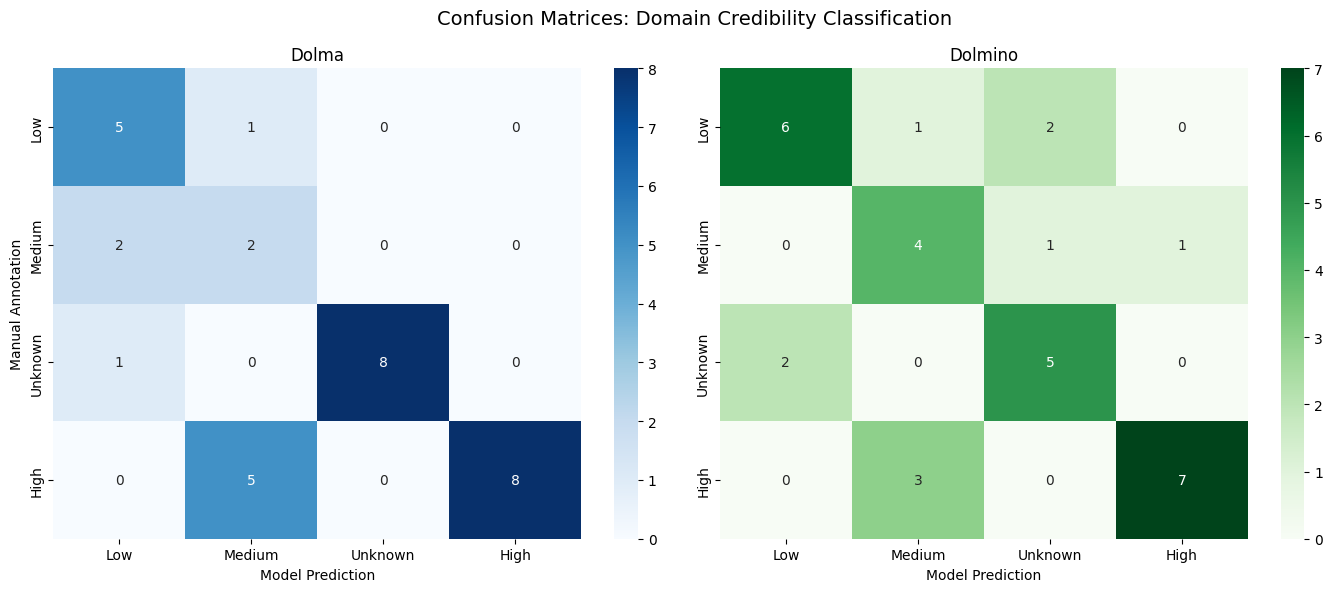

In [14]:

# Load your annotated file
file_path = "/content/domain_credibility_balanced_samples.xlsx"

df_dolma = pd.read_excel(file_path, sheet_name="Dolma_sample")
df_dolmino = pd.read_excel(file_path, sheet_name="Dolmino_sample")

def prepare_df(df):
    df = df.copy()
    df["source_credibility"] = df["source_credibility"].astype(str).str.strip().str.lower()
    df["manual_label"] = df["manual_label"].astype(str).str.strip().str.lower()
    df = df[df["manual_label"] != ""].copy()
    return df

df_dolma = prepare_df(df_dolma)
df_dolmino = prepare_df(df_dolmino)

# Define consistent label order (important!)
labels = ["low", "medium", "unknown", "high"]

# Compute confusion matrices
cm_dolma = confusion_matrix(df_dolma["manual_label"], df_dolma["source_credibility"], labels=labels)
cm_dolmino = confusion_matrix(df_dolmino["manual_label"], df_dolmino["source_credibility"], labels=labels)

# Pretty label names
pretty_labels = ["Low", "Medium", "Unknown", "High"]

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Dolma
sns.heatmap(cm_dolma,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=pretty_labels,
            yticklabels=pretty_labels,
            ax=axes[0])
axes[0].set_title("Dolma")
axes[0].set_xlabel("Model Prediction")
axes[0].set_ylabel("Manual Annotation")

# Dolmino
sns.heatmap(cm_dolmino,
            annot=True,
            fmt="d",
            cmap="Greens",
            xticklabels=pretty_labels,
            yticklabels=pretty_labels,
            ax=axes[1])
axes[1].set_title("Dolmino")
axes[1].set_xlabel("Model Prediction")
axes[1].set_ylabel("")

plt.suptitle("Confusion Matrices: Domain Credibility Classification", fontsize=14)
plt.tight_layout()
plt.show()

#credibility in different data, Left/right

In [ ]:
def credibility_distribution(df, credibility_col="source_credibility", normalize=True):
    """
    Returns overall credibility distribution.
    """
    dist = df[credibility_col].value_counts(normalize=normalize, dropna=False)
    if normalize:
        dist = dist * 100
    return dist


def credibility_by_bias(df, bias_col="llama_label", credibility_col="source_credibility", normalize="index"):
    """
    Returns crosstab of political bias vs source credibility.
    normalize='index' gives row percentages.
    """
    table = pd.crosstab(
        df[bias_col],
        df[credibility_col],
        normalize=normalize
    ) * 100
    return table


def plot_credibility_by_bias(
    df,
    bias_col="llama_label",
    credibility_col="source_credibility",
    normalize="index",
    figsize=(8, 5),
    title="Source Credibility by Political Bias"
):
    """
    Plots credibility distribution across political bias groups.
    """
    table = credibility_by_bias(
        df,
        bias_col=bias_col,
        credibility_col=credibility_col,
        normalize=normalize
    )

    ax = table.T.plot(kind="bar", figsize=figsize)
    plt.title(title)
    plt.ylabel("Percentage (%)")
    plt.xlabel("Credibility Level")
    plt.legend(title="Political Bias")
    plt.xticks(rotation=0)
    plt.show()

    return table


def credibility_summary(df, bias_col="llama_label", credibility_col="source_credibility"):
    """
    Prints quick summary and returns both overall and by-bias tables.
    """
    overall = credibility_distribution(df, credibility_col=credibility_col, normalize=True)
    by_bias = credibility_by_bias(df, bias_col=bias_col, credibility_col=credibility_col, normalize="index")

    print("Overall credibility distribution (%):")
    print(overall)
    print("\nCredibility by political bias (%):")
    print(by_bias)

    return overall, by_bias

Overall credibility distribution (%):
source_credibility
UNKNOWN    77.710221
MEDIUM     12.401055
LOW         6.682345
HIGH        3.206378
Name: proportion, dtype: float64

Credibility by political bias (%):
source_credibility      HIGH       LOW     MEDIUM    UNKNOWN
llama_label                                                 
left                3.534011   2.75215  13.252541  80.461298
right               2.304048  17.50646  10.055986  70.133506


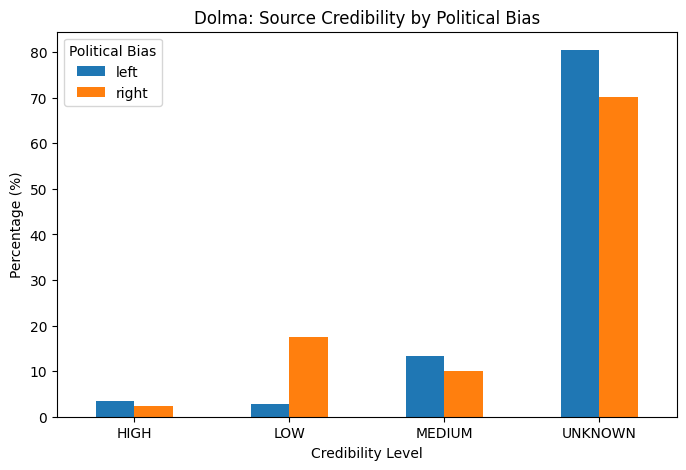

source_credibility,HIGH,LOW,MEDIUM,UNKNOWN
llama_label,,,,
left,3.534011,2.75215,13.252541,80.461298
right,2.304048,17.50646,10.055986,70.133506


In [ ]:
#1. Dolma analysis
dolma_overall, dolma_by_bias = credibility_summary(dolma_merged)

plot_credibility_by_bias(
    dolma_merged,
    title="Dolma: Source Credibility by Political Bias"
)

Overall credibility distribution (%):
source_credibility
UNKNOWN    65.437424
MEDIUM     17.849184
LOW        10.430594
HIGH        6.282798
Name: proportion, dtype: float64

Credibility by political bias (%):
source_credibility      HIGH        LOW     MEDIUM    UNKNOWN
llama_label                                                  
left                7.155737   4.536396  18.420803  69.887065
right               3.556609  28.838174  16.064019  51.541197


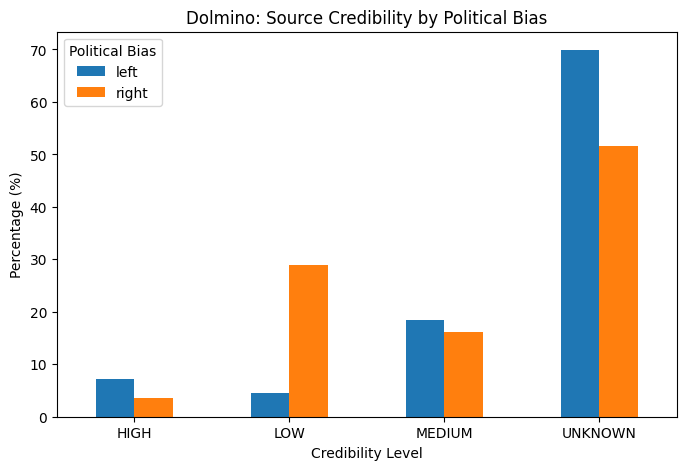

source_credibility,HIGH,LOW,MEDIUM,UNKNOWN
llama_label,,,,
left,7.155737,4.536396,18.420803,69.887065
right,3.556609,28.838174,16.064019,51.541197


In [ ]:
#2. Dolmino analysis
dolmino_overall, dolmino_by_bias = credibility_summary(dolmino_merged)

plot_credibility_by_bias(
    dolmino_merged,
    title="Dolmino: Source Credibility by Political Bias"
)

In [ ]:
#3. Direct comparison
print("Dolma:\n", dolma_by_bias)
print("\nDolmino:\n", dolmino_by_bias)

Dolma:
 source_credibility      HIGH       LOW     MEDIUM    UNKNOWN
llama_label                                                 
left                3.534011   2.75215  13.252541  80.461298
right               2.304048  17.50646  10.055986  70.133506

Dolmino:
 source_credibility      HIGH        LOW     MEDIUM    UNKNOWN
llama_label                                                  
left                7.155737   4.536396  18.420803  69.887065
right               3.556609  28.838174  16.064019  51.541197


In [ ]:
#4. Difference table
credibility_diff = dolmino_by_bias - dolma_by_bias
print("Difference (Dolmino - Dolma):\n", credibility_diff)

Difference (Dolmino - Dolma):
 source_credibility      HIGH        LOW    MEDIUM    UNKNOWN
llama_label                                                 
left                3.621726   1.784245  5.168262 -10.574233
right               1.252561  11.331714  6.008033 -18.592308


In [ ]:

def plot_credibility_comparison(dolma_df, dolmino_df,
                                bias_col="llama_label",
                                credibility_col="source_credibility"):

    dolma = pd.crosstab(
        dolma_df[bias_col],
        dolma_df[credibility_col],
        normalize="index"
    ) * 100

    dolmino = pd.crosstab(
        dolmino_df[bias_col],
        dolmino_df[credibility_col],
        normalize="index"
    ) * 100

    # remove UNKNOWN
    dolma = dolma.drop(columns=["UNKNOWN"], errors="ignore")
    dolmino = dolmino.drop(columns=["UNKNOWN"], errors="ignore")

    # align
    dolma, dolmino = dolma.align(dolmino, fill_value=0)

    # combine
    combined = pd.concat(
        {"Dolma": dolma, "Dolmino": dolmino},
        axis=0
    )

    # 🔥 custom colors (clear logic)
    colors = [
        "#9ecae1",  # Dolma left (light blue)
        "#fb6a4a",  # Dolma right (light red)
        "#08519c",  # Dolmino left (dark blue)
        "#cb181d"   # Dolmino right (dark red)
    ]

    ax = combined.T.plot(kind="bar", figsize=(10,6), color=colors)

    plt.title("Credibility Comparison")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Credibility Level")
    plt.xticks(rotation=0)

    plt.legend(title="Dataset & Bias", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

    return combined

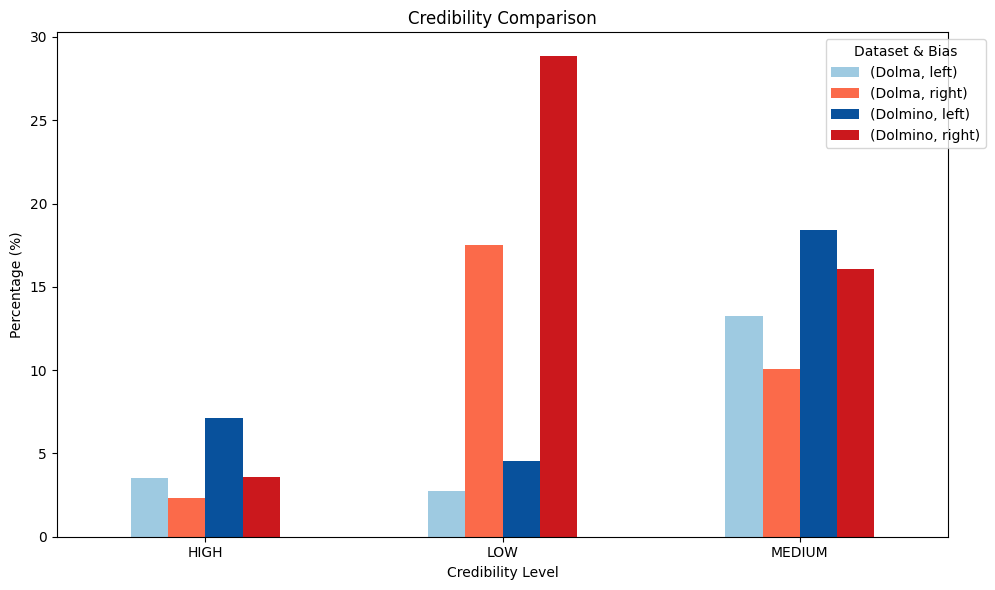

source_credibility       HIGH        LOW     MEDIUM
        llama_label                                
Dolma   left         3.534011   2.752150  13.252541
        right        2.304048  17.506460  10.055986
Dolmino left         7.155737   4.536396  18.420803
        right        3.556609  28.838174  16.064019

In [ ]:
plot_credibility_comparison(dolma_merged, dolmino_merged)

In [ ]:
#UNKNOWN analysis
def analyze_unknown(df, bias_col="llama_label", credibility_col="source_credibility"):
    """
    Analyzes how much of the dataset has UNKNOWN credibility.
    Returns summary stats and breakdown by political bias.
    """

    total = len(df)
    unknown_count = (df[credibility_col] == "UNKNOWN").sum()
    unknown_pct = (unknown_count / total) * 100

    print("Total rows:", total)
    print("UNKNOWN rows:", unknown_count)
    print("UNKNOWN percentage: {:.2f}%".format(unknown_pct))

    # breakdown by bias
    unknown_by_bias = pd.crosstab(
        df[bias_col],
        df[credibility_col] == "UNKNOWN",
        normalize="index"
    ) * 100

    unknown_by_bias = unknown_by_bias.rename(columns={True: "UNKNOWN", False: "KNOWN"})

    print("\nUNKNOWN vs KNOWN by bias (%):")
    print(unknown_by_bias)

    return {
        "total": total,
        "unknown_count": unknown_count,
        "unknown_pct": unknown_pct,
        "by_bias": unknown_by_bias
    }

dolma_unknown = analyze_unknown(dolma_merged)

print("\n" + "="*40 + "\n")

dolmino_unknown = analyze_unknown(dolmino_merged)

Total rows: 17434
UNKNOWN rows: 13548
UNKNOWN percentage: 77.71%

UNKNOWN vs KNOWN by bias (%):
source_credibility      KNOWN    UNKNOWN
llama_label                             
left                19.538702  80.461298
right               29.866494  70.133506


Total rows: 13911
UNKNOWN rows: 9103
UNKNOWN percentage: 65.44%

UNKNOWN vs KNOWN by bias (%):
source_credibility      KNOWN    UNKNOWN
llama_label                             
left                30.112935  69.887065
right               48.458803  51.541197


Filtering reduced UNKNOWN by ~12 percentage points
reaons for a lot of unkown ->You already saw examples:

Reddit → always UNKNOWN

Blogs → UNKNOWN

Missing domains → UNKNOWN

A key limitation of this analysis is that credibility is assigned at the domain level, and a large proportion of sources could not be mapped to known credibility categories.

In [ ]:
#Analyze UNKNOWN sources
def analyze_unknown_sources(df, top_n=20):
    """
    Analyzes where UNKNOWN credibility comes from.
    Shows most frequent domains and source types.
    """

    unknown_df = df[df["source_credibility"] == "UNKNOWN"]

    print("Total UNKNOWN rows:", len(unknown_df))
    print("\nTop UNKNOWN domains:")
    print(unknown_df["domain"].value_counts().head(top_n))

    print("\nTop UNKNOWN sources (dataset source column):")
    if "source" in df.columns:
        print(unknown_df["source"].value_counts().head(10))

    print("\nTop UNKNOWN source_domain (if exists):")
    if "source_domain" in df.columns:
        print(unknown_df["source_domain"].value_counts().head(10))

    return unknown_df

In [ ]:
dolma_unknown_df = analyze_unknown_sources(dolma_merged)

Total UNKNOWN rows: 13548

Top UNKNOWN domains:
domain
en.wikipedia.org            8
www.marxists.org            7
www.newsbreak.com           6
web.archive.org             6
www.change.org              6
www.questia.com             6
www.causes.com              6
www.hercampus.com           6
www.greenpeace.org          5
answers.yahoo.com           5
www.vanguardngr.com         4
zelo-street.blogspot.com    4
www.enotes.com              4
threadreaderapp.com         4
www.thehighroad.org         4
www.123helpme.com           4
www.mid-day.com             4
www.ncpa.org                4
www.towleroad.com           4
openparliament.ca           4
Name: count, dtype: int64

Top UNKNOWN sources (dataset source column):
source
common-crawl               5516
reddit                     4728
falcon-refinedweb/data     2232
c4                          901
flan_v2                     111
s2                           35
megawika                     13
wikipedia                     8
redpajama/

In [ ]:
print("\n" + "="*50 + "\n")
dolmino_unknown_df = analyze_unknown_sources(dolmino_merged)



Total UNKNOWN rows: 9103

Top UNKNOWN domains:
domain
www.studymode.com           26
en.wikipedia.org            25
www.writework.com           22
www.enotes.com              18
everything2.com             16
www.marxists.org            15
www.gradesaver.com          15
hubpages.com                14
www.debate.org              13
www.resilience.org          12
theimpudentobserver.com     11
www.shmoop.com              10
www.bartleby.com            10
brightkite.com              10
www.eff.org                  9
www.urbandictionary.com      9
www.ted.com                  9
atheistnexus.org             8
www.markedbyteachers.com     8
www.thewire.com              8
Name: count, dtype: int64

Top UNKNOWN sources (dataset source column):

Top UNKNOWN source_domain (if exists):
